In [2]:
# Install XGBoost
import sys
import subprocess

print("Installing XGBoost...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
print("Installation complete!")

Installing XGBoost...
Installation complete!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
import joblib
import os
from datetime import datetime

# Try to import XGBoost, if not available skip it
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost: Available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost: Not available (will use 2 models only)")

print("="*80)
print("STEP 4: MODEL TRAINING")
print("="*80)
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Load preprocessed data
print("Loading preprocessed data...")
X_train = pd.read_csv('data/preprocessed/X_train.csv')
y_train = pd.read_csv('data/preprocessed/y_train.csv').values.ravel()
X_test = pd.read_csv('data/preprocessed/X_test.csv')
y_test = pd.read_csv('data/preprocessed/y_test.csv').values.ravel()

print(f"\nData loaded successfully!")
print(f"  Training set: {X_train.shape}")
print(f"  Test set:     {X_test.shape}")
print(f"  Features:     {X_train.shape[1]}")

XGBoost: Available
STEP 4: MODEL TRAINING
Started: 2026-02-26 01:33:18

Loading preprocessed data...

Data loaded successfully!
  Training set: (35000, 25)
  Test set:     (15000, 25)
  Features:     25


In [4]:
print("="*80)
print("INITIALIZING MODELS")
print("="*80)

# Dictionary to store models
models = {}

# Model 1: Logistic Regression
print("\n1. Logistic Regression")
print("-"*80)
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
models['Logistic_Regression'] = lr_model
print("  Parameters:")
print(f"    max_iter: 1000")
print(f"    class_weight: balanced")
print(f"    solver: lbfgs")

# Model 2: Random Forest
print("\n2. Random Forest")
print("-"*80)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
models['Random_Forest'] = rf_model
print("  Parameters:")
print(f"    n_estimators: 100")
print(f"    max_depth: 10")
print(f"    class_weight: balanced")

# Model 3: XGBoost
print("\n3. XGBoost")
print("-"*80)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=3,
    eval_metric='logloss'
)
models['XGBoost'] = xgb_model
print("  Parameters:")
print(f"    n_estimators: 100")
print(f"    max_depth: 6")
print(f"    learning_rate: 0.1")
print(f"    scale_pos_weight: 3")

print(f"\n{len(models)} models initialized")

INITIALIZING MODELS

1. Logistic Regression
--------------------------------------------------------------------------------
  Parameters:
    max_iter: 1000
    class_weight: balanced
    solver: lbfgs

2. Random Forest
--------------------------------------------------------------------------------
  Parameters:
    n_estimators: 100
    max_depth: 10
    class_weight: balanced

3. XGBoost
--------------------------------------------------------------------------------
  Parameters:
    n_estimators: 100
    max_depth: 6
    learning_rate: 0.1
    scale_pos_weight: 3

3 models initialized


In [6]:
print("="*80)
print("TRAINING MODEL 1: LOGISTIC REGRESSION")
print("="*80)

start_time = datetime.now()

print("\nTraining...")
lr_model.fit(X_train, y_train)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"Training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1_Score': f1_score(y_test, y_pred_lr),
    'AUC_ROC': roc_auc_score(y_test, y_prob_lr)
}

print("\nPerformance Metrics:")
print("-"*80)
for metric, value in lr_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

TRAINING MODEL 1: LOGISTIC REGRESSION

Training...
Training completed in 0.27 seconds

Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9123
  Precision   : 0.7440
  Recall      : 0.9167
  F1_Score    : 0.8213
  AUC_ROC     : 0.9752


In [7]:
print("="*80)
print("TRAINING MODEL 2: RANDOM FOREST")
print("="*80)

start_time = datetime.now()

print("\nTraining...")
rf_model.fit(X_train, y_train)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"Training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1_Score': f1_score(y_test, y_pred_rf),
    'AUC_ROC': roc_auc_score(y_test, y_prob_rf)
}

print("\nPerformance Metrics:")
print("-"*80)
for metric, value in rf_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

TRAINING MODEL 2: RANDOM FOREST

Training...
Training completed in 5.71 seconds

Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9116
  Precision   : 0.7550
  Recall      : 0.8855
  F1_Score    : 0.8151
  AUC_ROC     : 0.9709


In [8]:
print("="*80)
print("TRAINING MODEL 3: XGBOOST")
print("="*80)

start_time = datetime.now()

print("\nTraining...")
xgb_model.fit(X_train, y_train)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds()

print(f"Training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1_Score': f1_score(y_test, y_pred_xgb),
    'AUC_ROC': roc_auc_score(y_test, y_prob_xgb)
}

print("\nPerformance Metrics:")
print("-"*80)
for metric, value in xgb_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

TRAINING MODEL 3: XGBOOST

Training...
Training completed in 1.23 seconds

Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy    : 0.9233
  Precision   : 0.7851
  Recall      : 0.8970
  F1_Score    : 0.8373
  AUC_ROC     : 0.9772


In [9]:
print("="*80)
print("MODEL COMPARISON")
print("="*80)

# Compile all metrics
all_metrics = pd.DataFrame({
    'Logistic_Regression': lr_metrics,
    'Random_Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T

print("\nPerformance Summary:")
print("="*80)
print(all_metrics.to_string())

# Find best model by AUC
best_model_name = all_metrics['AUC_ROC'].idxmax()
best_auc = all_metrics.loc[best_model_name, 'AUC_ROC']

print("\n" + "="*80)
print(f"BEST MODEL: {best_model_name}")
print(f"AUC-ROC: {best_auc:.4f}")
print("="*80)

# Store predictions for later use
predictions = {
    'Logistic_Regression': {'y_pred': y_pred_lr, 'y_prob': y_prob_lr},
    'Random_Forest': {'y_pred': y_pred_rf, 'y_prob': y_prob_rf},
    'XGBoost': {'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb}
}

MODEL COMPARISON

Performance Summary:
                     Accuracy  Precision    Recall  F1_Score   AUC_ROC
Logistic_Regression  0.912267   0.743974  0.916667  0.821341  0.975163
Random_Forest        0.911600   0.755039  0.885455  0.815063  0.970929
XGBoost              0.923333   0.785146  0.896970  0.837341  0.977226

BEST MODEL: XGBoost
AUC-ROC: 0.9772


Creating visualizations...
Visualization saved: data/model_comparison.png


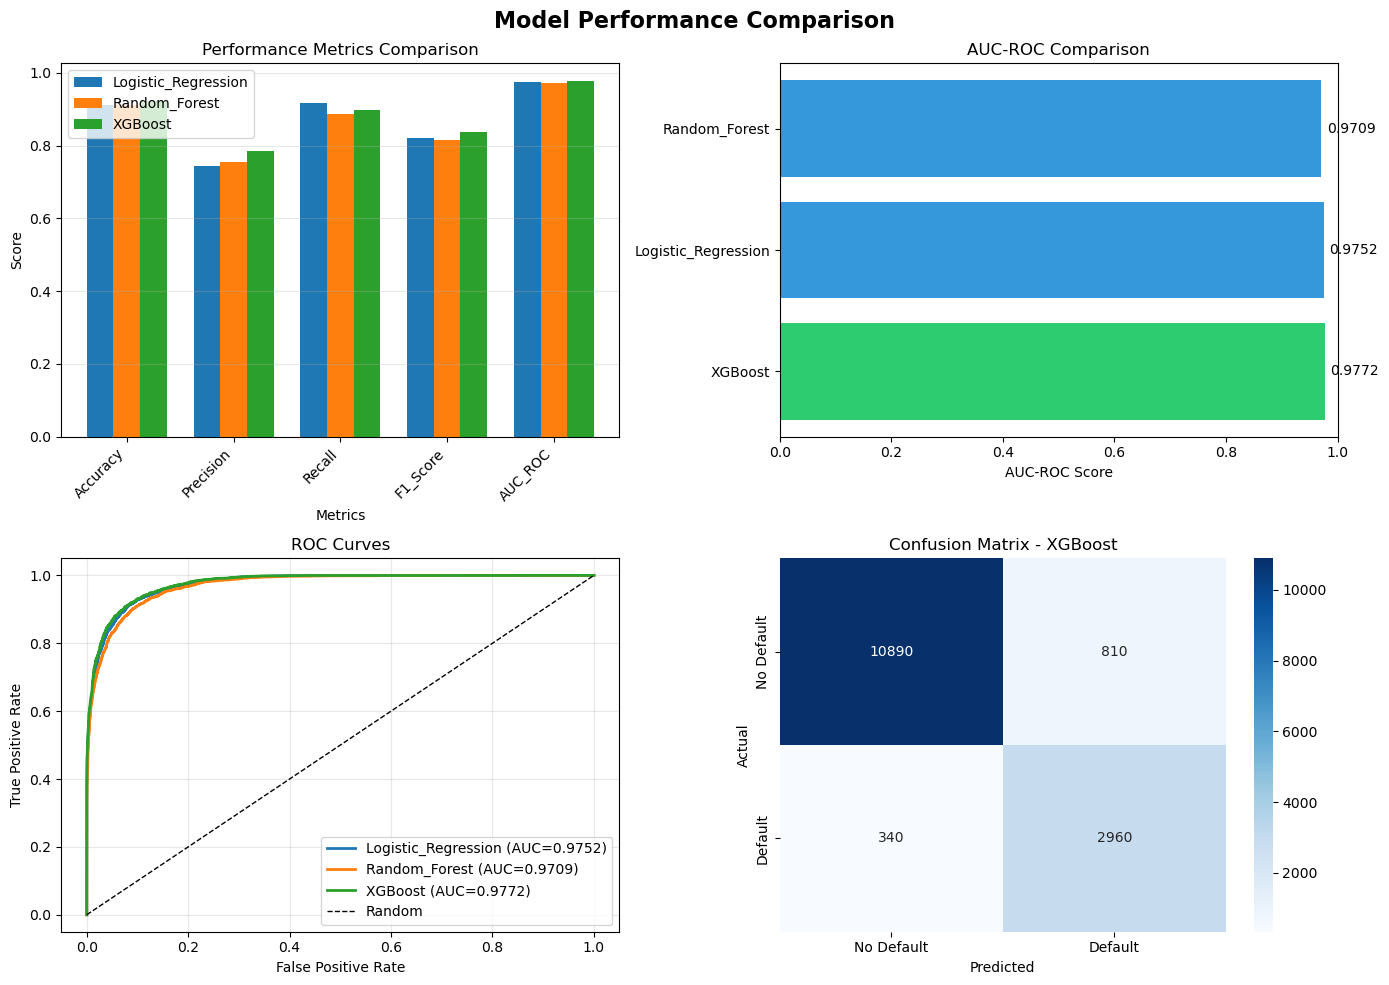

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Plot 1: Metrics Comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC']
x_pos = np.arange(len(metrics_to_plot))
width = 0.25

for i, model_name in enumerate(all_metrics.index):
    values = all_metrics.loc[model_name, metrics_to_plot].values
    axes[0, 0].bar(x_pos + i*width, values, width, label=model_name)

axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x_pos + width)
axes[0, 0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: AUC Comparison
auc_scores = all_metrics['AUC_ROC'].sort_values(ascending=False)
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(auc_scores))]
axes[0, 1].barh(range(len(auc_scores)), auc_scores.values, color=colors)
axes[0, 1].set_yticks(range(len(auc_scores)))
axes[0, 1].set_yticklabels(auc_scores.index)
axes[0, 1].set_xlabel('AUC-ROC Score')
axes[0, 1].set_title('AUC-ROC Comparison')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(auc_scores.values):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center')

# Plot 3: ROC Curves
for model_name, pred_data in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred_data['y_prob'])
    auc = roc_auc_score(y_test, pred_data['y_prob'])
    axes[1, 0].plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', linewidth=2)

axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Confusion Matrix for Best Model
best_predictions = predictions[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1, 1].set_xticklabels(['No Default', 'Default'])
axes[1, 1].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=300, bbox_inches='tight')
print("Visualization saved: data/model_comparison.png")
plt.show()

In [11]:
print("="*80)
print("SAVING BEST MODEL")
print("="*80)

# Create models directory
os.makedirs('models/trained', exist_ok=True)

# Get best model object
best_model_obj = models[best_model_name]

# Save best model
model_path = f'models/trained/best_model_{best_model_name}.pkl'
joblib.dump(best_model_obj, model_path)

print(f"\nBest model saved:")
print(f"  Model: {best_model_name}")
print(f"  Path: {model_path}")
print(f"  AUC-ROC: {best_auc:.4f}")

# Save all models for comparison
for model_name, model_obj in models.items():
    model_path = f'models/trained/{model_name}.pkl'
    joblib.dump(model_obj, model_path)
    print(f"\nSaved: {model_path}")

# Save metrics
metrics_path = 'data/model_metrics.csv'
all_metrics.to_csv(metrics_path)
print(f"\nMetrics saved: {metrics_path}")

SAVING BEST MODEL

Best model saved:
  Model: XGBoost
  Path: models/trained/best_model_XGBoost.pkl
  AUC-ROC: 0.9772

Saved: models/trained/Logistic_Regression.pkl

Saved: models/trained/Random_Forest.pkl

Saved: models/trained/XGBoost.pkl

Metrics saved: data/model_metrics.csv


In [12]:
print("="*80)
print("STEP 4 COMPLETE - TRAINING SUMMARY")
print("="*80)

print(f"""
TRAINING SUMMARY
{'='*80}

Models Trained:
  1. Logistic Regression
  2. Random Forest
  3. XGBoost

Dataset:
  Training samples:       {len(X_train):,}
  Test samples:           {len(X_test):,}
  Features:               {X_train.shape[1]}

Performance Results:
{'='*80}
{all_metrics.to_string()}

Best Model:
  Name:                   {best_model_name}
  AUC-ROC:                {best_auc:.4f}
  Accuracy:               {all_metrics.loc[best_model_name, 'Accuracy']:.4f}
  Precision:              {all_metrics.loc[best_model_name, 'Precision']:.4f}
  Recall:                 {all_metrics.loc[best_model_name, 'Recall']:.4f}

Files Created:
  - models/trained/best_model_{best_model_name}.pkl
  - models/trained/Logistic_Regression.pkl
  - models/trained/Random_Forest.pkl
  - models/trained/XGBoost.pkl
  - data/model_metrics.csv
  - data/model_comparison.png

Status: READY FOR STEP 5 (MODEL EVALUATION)
""")

print(f"Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

STEP 4 COMPLETE - TRAINING SUMMARY

TRAINING SUMMARY

Models Trained:
  1. Logistic Regression
  2. Random Forest
  3. XGBoost

Dataset:
  Training samples:       35,000
  Test samples:           15,000
  Features:               25

Performance Results:
                     Accuracy  Precision    Recall  F1_Score   AUC_ROC
Logistic_Regression  0.912267   0.743974  0.916667  0.821341  0.975163
Random_Forest        0.911600   0.755039  0.885455  0.815063  0.970929
XGBoost              0.923333   0.785146  0.896970  0.837341  0.977226

Best Model:
  Name:                   XGBoost
  AUC-ROC:                0.9772
  Accuracy:               0.9233
  Precision:              0.7851
  Recall:                 0.8970

Files Created:
  - models/trained/best_model_XGBoost.pkl
  - models/trained/Logistic_Regression.pkl
  - models/trained/Random_Forest.pkl
  - models/trained/XGBoost.pkl
  - data/model_metrics.csv
  - data/model_comparison.png

Status: READY FOR STEP 5 (MODEL EVALUATION)

Completed: 